# UNR tenv3 EDA → xarray NetCDF (header-aware)

This notebook:
- Summarizes the **download manifest**
- Reads UNR `.tenv3` files using the **header line** (robust to column re-ordering)
- Filters to stations with **>5 years** of data within **2010 → present**
- Builds a **provider-specific NetCDF** (UNR) compatible with xarray

Constraints:
- Displacements and sigmas in **meters**
- Station metadata limited to **lat, lon, alt_m**


In [1]:
from __future__ import annotations

from pathlib import Path
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pandas.core.dtypes.common import pandas_dtype

plt.rcParams["figure.dpi"] = 140


## 1) Inputs

Set these paths to your local folders.

In [3]:
DATA_DIR = Path("./data/unr_tenv3")          # directory containing *.tenv3
MANIFEST = Path("./data/unr_outputs/manifest.csv")   # produced by downloader

assert DATA_DIR.exists(), f"Missing {DATA_DIR.resolve()}"
assert MANIFEST.exists(), f"Missing {MANIFEST.resolve()}"
print("OK:", DATA_DIR, MANIFEST)


OK: data\unr_tenv3 data\unr_outputs\manifest.csv


## 2) Manifest summary

In [4]:
manifest = pd.read_csv(MANIFEST)
display(manifest.head())

print("Total:", len(manifest))
print(manifest["status"].value_counts())


,station,url,status,http_status,bytes,path,error
0,ABBY,https://geodesy.unr.edu/gps_timeseries/IGS20/t...,skipped_existing,NaN,264588.0,data\unr_tenv3\ABBY.tenv3,NaN
1,ABOT,https://geodesy.unr.edu/gps_timeseries/IGS20/t...,skipped_existing,NaN,356388.0,data\unr_tenv3\ABOT.tenv3,NaN
2,AGNS,https://geodesy.unr.edu/gps_timeseries/IGS20/t...,skipped_existing,NaN,333132.0,data\unr_tenv3\AGNS.tenv3,NaN
3,AL2H,https://geodesy.unr.edu/gps_timeseries/IGS20/t...,skipped_existing,NaN,573852.0,data\unr_tenv3\AL2H.tenv3,NaN
4,ALB4,https://geodesy.unr.edu/gps_timeseries/IGS20/t...,skipped_existing,NaN,411264.0,data\unr_tenv3\ALB4.tenv3,NaN


Total: 570
status
skipped_existing    568
not_found             2
Name: count, dtype: int64


## 3) Header-aware UNR tenv3 reader

In [21]:
def _normalize_col(c: str) -> str:
    c = re.sub(r"\s+", "_", c.strip())
    c = re.sub(r"_+", "_", c)
    return c.strip("_").lower()

def read_tenv3_headered(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        header = ""
        for line in f:
            line = line.strip()
            if line:
                header = line
                break
    if not header:
        raise ValueError(f"No header found in {path}")

    cols = [_normalize_col(x) for x in header.split()]

    df = pd.read_csv(
        path,
        sep='\\s+',
        names=cols,
        skiprows=1,
        comment="#",
        engine="python",
    )
    return df

def pick_col(df: pd.DataFrame, token: str) -> str:
    norm_cols = {c: _normalize_col(c) for c in df.columns}
    hits = [orig for orig, norm in norm_cols.items() if norm.endswith(token)]
    if not hits:
        raise KeyError(f"Missing column ending with '{token}'. Available: {list(df.columns)}")
    return hits[0]

def tenv3_to_clean(df: pd.DataFrame) -> pd.DataFrame:
    dec_year = pd.to_numeric(df[pick_col(df, "yyyy.yyyy")], errors="coerce")

    out = pd.DataFrame({
        "dec_year": dec_year,
        "east_m": pd.to_numeric(df[pick_col(df, "east(m)")], errors="coerce"),
        "north_m": pd.to_numeric(df[pick_col(df, "north(m)")], errors="coerce"),
        "up_m": pd.to_numeric(df[pick_col(df, "up(m)")], errors="coerce"),
        "east_sigma_m": pd.to_numeric(df[pick_col(df, "sig_e(m)")], errors="coerce"),
        "north_sigma_m": pd.to_numeric(df[pick_col(df, "sig_n(m)")], errors="coerce"),
        "up_sigma_m": pd.to_numeric(df[pick_col(df, "sig_u(m)")], errors="coerce"),
        "lat": pd.to_numeric(df[pick_col(df, "latitude(deg)")], errors="coerce"),
        "lon": pd.to_numeric(df[pick_col(df, "longitude(deg)")], errors="coerce"),
        "alt_m": pd.to_numeric(df[pick_col(df, "height(m)")], errors="coerce"),
    })

    out = out.dropna(subset=["dec_year", "east_m", "north_m", "up_m"]).reset_index(drop=True)
    return out


## 4) Inspect one station

In [12]:
# Treat downloaded + skipped_existing as "usable"
manifest["status_norm"] = manifest["status"].astype(str).str.strip().str.lower()

ok = manifest[manifest["status_norm"].isin({"downloaded", "skipped_existing"})].copy()
assert len(ok) > 0, "No usable stations (downloaded or skipped_existing) in manifest."

sample_station = ok.iloc[0]["station"]
path = DATA_DIR / f"{sample_station}.tenv3"

raw = read_tenv3_headered(path)
ts = tenv3_to_clean(raw)

display(ts.head())
print("Rows:", len(ts))
print("Span (years):", float(ts.dec_year.max() - ts.dec_year.min()))

,dec_year,east_m,north_m,up_m,east_sigma_m,north_sigma_m,up_sigma_m,lat,lon,alt_m
0,2015.3511,0.582133,0.503238,0.290391,0.000884,0.001342,0.003771,49.072141,-122.197802,195.29039
1,2015.3539,0.580691,0.501074,0.290452,0.000694,0.000994,0.002991,49.072141,-122.197802,195.29045
2,2015.3566,0.580330,0.501224,0.294340,0.000710,0.001034,0.003005,49.072141,-122.197802,195.29434
3,2015.3593,0.580050,0.500240,0.295943,0.000723,0.001068,0.003170,49.072141,-122.197802,195.29594
4,2015.3621,0.579422,0.499995,0.293462,0.000769,0.001072,0.003278,49.072141,-122.197802,195.29346


Rows: 1296
Span (years): 7.646799999999985


### Quick NEU plot

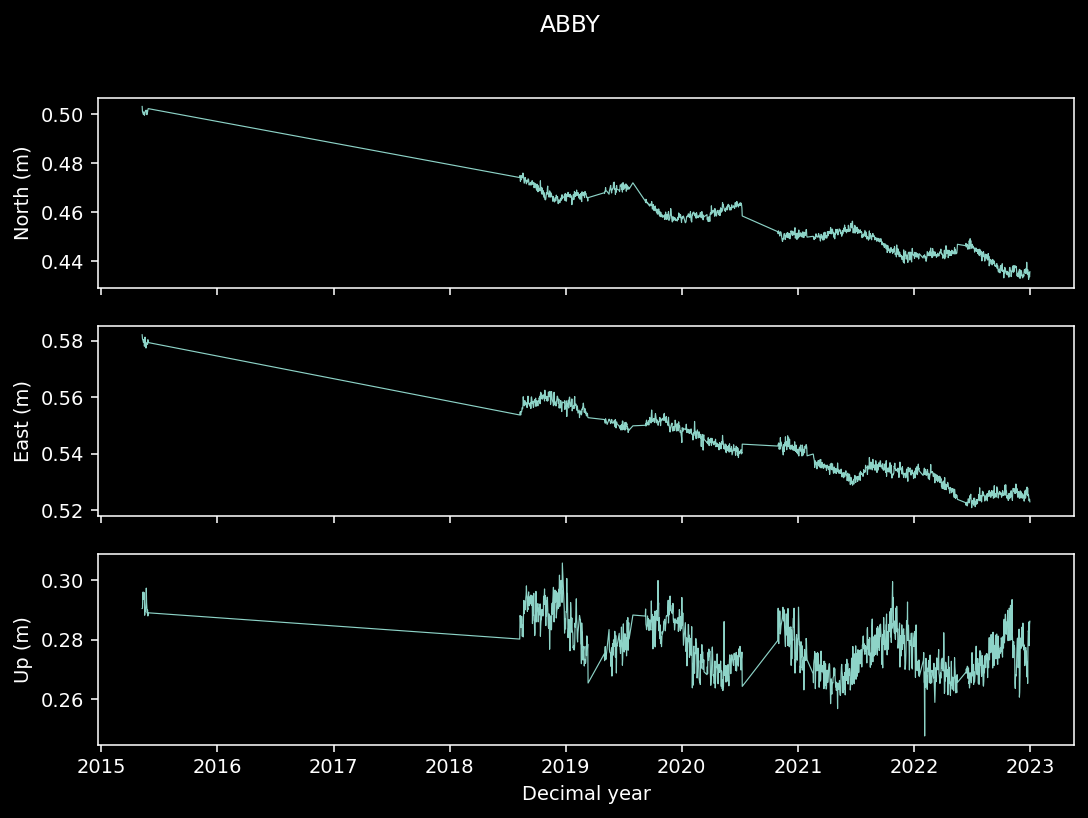

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

ax[0].plot(ts.dec_year, ts.north_m, lw=0.6)
ax[0].set_ylabel("North (m)")

ax[1].plot(ts.dec_year, ts.east_m, lw=0.6)
ax[1].set_ylabel("East (m)")

ax[2].plot(ts.dec_year, ts.up_m, lw=0.6)
ax[2].set_ylabel("Up (m)")
ax[2].set_xlabel("Decimal year")

plt.suptitle(sample_station)
plt.show()


## 5) Apply filters: 2010→present and >5 years

In [14]:
START_YEAR = 2010.0
END_YEAR = datetime.utcnow().year + 1
MIN_YEARS = 5.0

def filter_window(ts: pd.DataFrame) -> pd.DataFrame:
    return ts[(ts.dec_year >= START_YEAR) & (ts.dec_year <= END_YEAR)].copy()

def has_min_span(ts: pd.DataFrame, min_years: float = MIN_YEARS) -> bool:
    if ts.empty:
        return False
    return float(ts.dec_year.max() - ts.dec_year.min()) >= float(min_years)

valid, invalid = [], []

for st in ok.station.tolist():
    p = DATA_DIR / f"{st}.tenv3"
    try:
        ts0 = filter_window(tenv3_to_clean(read_tenv3_headered(p)))
        if has_min_span(ts0):
            valid.append(st)
        else:
            invalid.append(st)
    except Exception:
        invalid.append(st)

print("Valid stations:", len(valid))
print("Filtered out / failed parse:", len(invalid))
valid[:10]


C:\Users\loicb\AppData\Local\Temp\ipykernel_29544\2571909808.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  END_YEAR = datetime.utcnow().year + 1


Valid stations: 486
Filtered out / failed parse: 82


['ABBY',
 'ABOT',
 'AL2H',
 'ALB4',
 'ALBH',
 'ARLI',
 'ASBU',
 'ASHL',
 'BAMF',
 'BBAY']

## Step 6: xarray Dataset with dims (time, station) and station coords from catalog


### 1) Build a station metadata table from your station CSV/catalog.
    If your catalog df is called `cat`, it should have: name, lat, lon, elev_m, and maybe depth_m.

In [17]:
cat = pd.read_csv("./resources/catalog_subset_bbox.csv")

meta_df = cat.set_index("name").copy()

# Optional: handle missing depth column
if "depth_m" not in meta_df.columns:
    meta_df["depth_m"] = np.nan

# Optional: handle missing station id
if "id" not in meta_df.columns:
    meta_df["id"] = pd.NA


def mjd_to_datetime64(mjd_series: pd.Series) -> np.ndarray:
    # MJD 0 = 1858-11-17
    mjd0 = np.datetime64("1858-11-17")
    # mjd might be float; round to nearest day for daily products
    days = np.round(pd.to_numeric(mjd_series, errors="coerce")).astype("Int64")
    return (mjd0 + days.astype("timedelta64[D]")).to_numpy(dtype="datetime64[ns]")


def station_to_daily_frame(st: str) -> pd.DataFrame:
    raw = read_tenv3_headered(DATA_DIR / f"{st}.tenv3")

    # pick columns robustly (using your existing helpers)
    col_mjd = None
    try:
        col_mjd = pick_col(raw, "mjd")
    except Exception:
        col_mjd = None

    if col_mjd is not None:
        time = mjd_to_datetime64(raw[col_mjd])
    else:
        # fallback: parse YYMMMDD (like 10JAN01 etc)
        col_date = pick_col(raw, "yymmmdd")
        # pandas can parse many formats; this one needs a tiny nudge
        time = pd.to_datetime(raw[col_date].astype(str), format="%y%b%d", errors="coerce").to_numpy(dtype="datetime64[ns]")

    ts = tenv3_to_clean(raw)

    # tenv3_to_clean gives dec_year-based rows; we need to align its rows with `raw` rows.
    # Since tenv3_to_clean was derived from raw, they should be same length/order after dropping NaNs.
    # So re-create a clean df directly from raw to avoid misalignment:
    df = pd.DataFrame({
        "time": time,
        "east_m": pd.to_numeric(raw[pick_col(raw, "east(m)")], errors="coerce"),
        "north_m": pd.to_numeric(raw[pick_col(raw, "north(m)")], errors="coerce"),
        "up_m": pd.to_numeric(raw[pick_col(raw, "up(m)")], errors="coerce"),
        "east_sigma_m": pd.to_numeric(raw[pick_col(raw, "sig_e(m)")], errors="coerce"),
        "north_sigma_m": pd.to_numeric(raw[pick_col(raw, "sig_n(m)")], errors="coerce"),
        "up_sigma_m": pd.to_numeric(raw[pick_col(raw, "sig_u(m)")], errors="coerce"),
        "dec_year": pd.to_numeric(raw[pick_col(raw, "yyyy.yyyy")], errors="coerce"),
    }).dropna(subset=["time", "east_m", "north_m", "up_m"])

    # Filter to 2010 → present using datetime (cleaner)
    start = np.datetime64("2010-01-01")
    end = np.datetime64("today")  # numpy 'today' is day precision
    df = df[(df["time"] >= start) & (df["time"] <= end)].copy()

    # Set daily index
    df = df.set_index("time").sort_index()

    # If multiple entries per day exist (rare), average them (or pick last)
    df = df.groupby(level=0).mean(numeric_only=True)

    return df[["east_m","north_m","up_m","east_sigma_m","north_sigma_m","up_sigma_m"]]

### 2) Define a common daily time axis

In [19]:
start = pd.Timestamp("2010-01-01")
end   = pd.Timestamp("2025-12-31")
time_index = pd.date_range(start, end, freq="D")
time = time_index.to_numpy(dtype="datetime64[ns]")

stations = np.array(sorted(valid))  # your valid station list after >5y check

var_names = ["east_m","north_m","up_m","east_sigma_m","north_sigma_m","up_sigma_m"]
data = {v: np.full((len(time), len(stations)), np.nan, dtype=np.float32) for v in var_names}

### 3) Fill arrays by reindexing each station onto the common daily axis

In [22]:
for j, st in enumerate(stations):
    fr = station_to_daily_frame(st)
    fr = fr.reindex(time_index)  # align to daily grid, gaps become NaN
    for v in var_names:
        data[v][:, j] = fr[v].to_numpy(dtype=np.float32)

### 4) Station coords from catalog (CSV) — this is your preferred provenance source

In [23]:
lat = np.array([meta_df.loc[s, "lat"] if s in meta_df.index else np.nan for s in stations], dtype=np.float64)
lon = np.array([meta_df.loc[s, "lon"] if s in meta_df.index else np.nan for s in stations], dtype=np.float64)
elev_m = np.array([meta_df.loc[s, "elev_m"] if s in meta_df.index else np.nan for s in stations], dtype=np.float64)
depth_m = np.array([meta_df.loc[s, "depth_m"] if s in meta_df.index else np.nan for s in stations], dtype=np.float64)
station_id = np.array([meta_df.loc[s, "id"] if s in meta_df.index else pd.NA for s in stations], dtype="object")

ds_unr = xr.Dataset(
    data_vars={v: (("time","station"), arr) for v, arr in data.items()},
    coords={
        "time": ("time", time),
        "station": ("station", stations),
        "station_id": ("station", station_id),
        "lat": ("station", lat),
        "lon": ("station", lon),
        "elev_m": ("station", elev_m),
        "depth_m": ("station", depth_m),
    },
    attrs={
        "provider": "UNR",
        "source": "UNR tenv3",
        "time_coord": "datetime64 daily",
        "time_range": "2010-01-01 to 2025-12-31",
        "min_years": 5,
        "units": "meters",
    }
)

ds_unr


<xarray.Dataset> Size: 68MB
Dimensions:        (time: 5844, station: 486)
Coordinates:
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-31
  * station        (station) <U4 8kB 'ABBY' 'ABOT' 'AL2H' ... 'YONC' 'ZSE1'
    station_id     (station) object 4kB 686 731 987 1021 ... 20167 20171 20346
    lat            (station) float64 4kB 49.07 49.03 48.39 ... 45.38 43.63 47.29
    lon            (station) float64 4kB -122.2 -122.3 -123.5 ... -123.3 -122.2
    elev_m         (station) float64 4kB 195.3 -4.009 31.75 ... 86.49 82.06
    depth_m        (station) float64 4kB nan nan nan nan nan ... nan nan nan nan
Data variables:
    east_m         (time, station) float32 11MB nan nan nan nan ... nan nan nan
    north_m        (time, station) float32 11MB nan nan nan nan ... nan nan nan
    up_m           (time, station) float32 11MB nan nan nan nan ... nan nan nan
    east_sigma_m   (time, station) float32 11MB nan nan nan nan ... nan nan nan
    north_sigma_m  (time, station) float32 11MB nan nan nan nan ... nan nan nan
    up_sigma_m     (time, station) float32 11MB nan nan nan nan ... nan nan nan
Attributes:
    provider:    UNR
    source:      UNR tenv3
    time_coord:  datetime64 daily
    time_range:  2010-01-01 to 2025-12-31
    min_years:   5
    units:       meters

## 7) Write NetCDF (UNR)

In [26]:
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)
OUT_NC = OUT_DIR / "gnss_unr_2010_2025_5y.nc"

encoding = {v: {"zlib": True, "complevel": 4} for v in ds_unr.data_vars}
ds_unr.to_netcdf(OUT_NC, encoding=encoding)
print("Wrote:", OUT_NC)


Wrote: outputs\gnss_unr_2010_2025_5y.nc


## 8) Smoke test: reopen and plot one station

<xarray.Dataset> Size: 68MB
Dimensions:        (time: 5844, station: 486)
Coordinates:
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-31
  * station        (station) <U4 8kB 'ABBY' 'ABOT' 'AL2H' ... 'YONC' 'ZSE1'
    station_id     (station) int64 4kB ...
    lat            (station) float64 4kB ...
    lon            (station) float64 4kB ...
    elev_m         (station) float64 4kB ...
    depth_m        (station) float64 4kB ...
Data variables:
    east_m         (time, station) float32 11MB ...
    north_m        (time, station) float32 11MB ...
    up_m           (time, station) float32 11MB ...
    east_sigma_m   (time, station) float32 11MB ...
    north_sigma_m  (time, station) float32 11MB ...
    up_sigma_m     (time, station) float32 11MB ...
Attributes:
    provider:    UNR
    source:      UNR tenv3
    time_coord:  datetime64 daily
    time_range:  2010-01-01 to 2025-12-31
    min_years:   5
    units:       meters


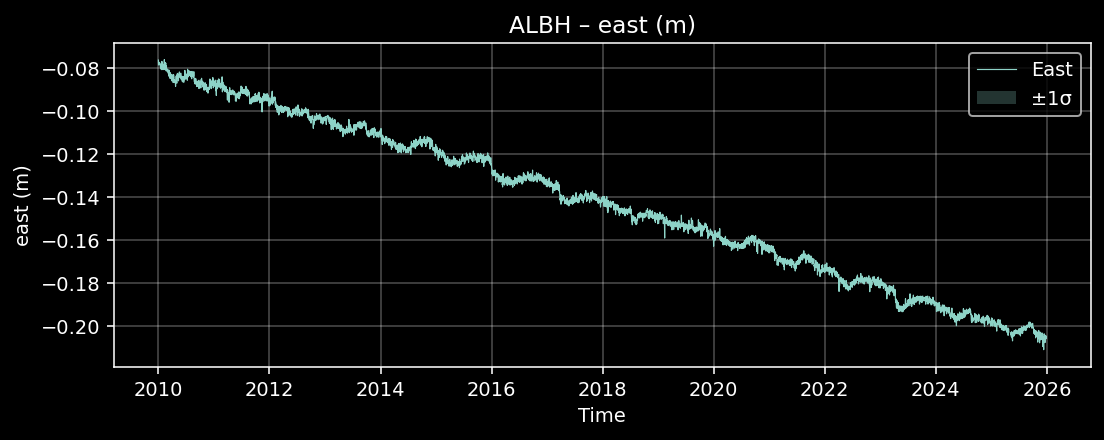

In [30]:
ds = xr.open_dataset(OUT_NC)
print(ds)

st = "ALBH"
sel = ds.sel(station=st)

plt.figure(figsize=(9, 3))

# central value
plt.plot(sel.time, sel.east_m, lw=0.6, label="East")

# ±1σ envelope
plt.fill_between(
    sel.time,
    sel.east_m - sel.east_sigma_m,
    sel.east_m + sel.east_sigma_m,
    alpha=0.25,
    linewidth=0,
    label="±1σ"
)

plt.title(f"{st} – east (m)")
plt.xlabel("Time")
plt.ylabel("east (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


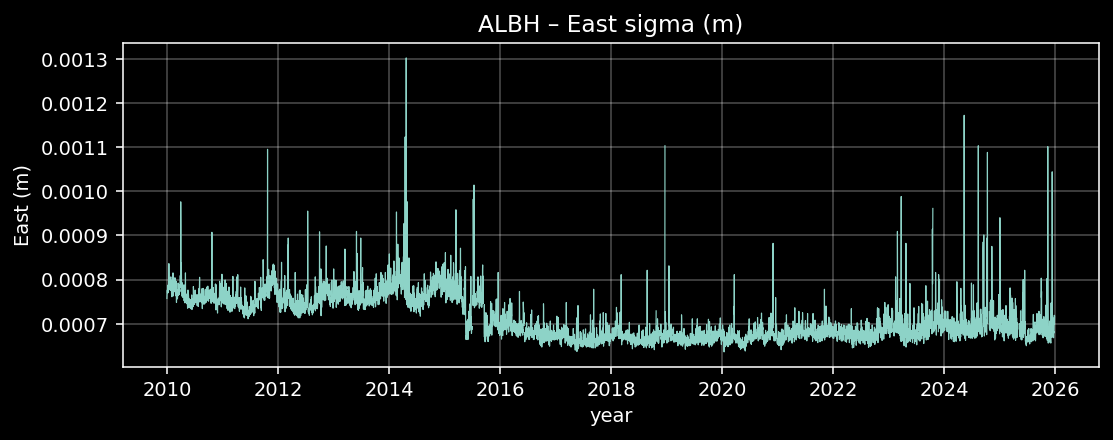

In [34]:
plt.figure(figsize=(9,3))
plt.plot(sel.time, sel.east_sigma_m, lw=0.6)
plt.title(f"{st} – East sigma (m)")
plt.xlabel("year")
plt.ylabel("East (m)")
plt.grid(True, alpha=0.3)
plt.show()